In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

In [2]:
#loading the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
#data Analysis
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [4]:
#data preprocessing =>data flaterning

x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

#one hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)


In [5]:
# Build model function
def build_model():
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Fixed Learning Rate
model_fixed = build_model()

optimizer_fixed = keras.optimizers.Adam(learning_rate=0.001)    #learning rate = 0.001

model_fixed.compile(                  #compile model
    optimizer=optimizer_fixed,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9081 - loss: 0.3150 - val_accuracy: 0.9542 - val_loss: 0.1513
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9644 - loss: 0.1158 - val_accuracy: 0.9697 - val_loss: 0.1033
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9774 - loss: 0.0761 - val_accuracy: 0.9705 - val_loss: 0.0987
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9829 - loss: 0.0552 - val_accuracy: 0.9691 - val_loss: 0.1041
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9865 - loss: 0.0416 - val_accuracy: 0.9736 - val_loss: 0.0929
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9886 - loss: 0.0337 - val_accuracy: 0.9743 - val_loss: 0.0914
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9922 - loss: 0.0249 - val_accuracy: 0.9762 - val_loss: 0.0899
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9941 - loss: 0.0179 - val_accuracy: 

In [6]:
# Learning Rate Decay
#learning rate changes automatically during training
lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,                 #after every decay steps reduce learning rate
    decay_rate=0.9                    #multiply learning rate with decay rate
)

model_decay = build_model()

optimizer_decay = keras.optimizers.Adam(learning_rate=lr_schedule)

model_decay.compile(
    optimizer=optimizer_decay,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_decay = model_decay.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9066 - loss: 0.3189 - val_accuracy: 0.9572 - val_loss: 0.1499
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9645 - loss: 0.1184 - val_accuracy: 0.9672 - val_loss: 0.1167
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9757 - loss: 0.0792 - val_accuracy: 0.9723 - val_loss: 0.0981
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9830 - loss: 0.0560 - val_accuracy: 0.9727 - val_loss: 0.0927
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9879 - loss: 0.0397 - val_accuracy: 0.9747 - val_loss: 0.0902
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9902 - loss: 0.0313 - val_accuracy: 0.9747 - val_loss: 0.0908
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9761 - val_loss: 0.0834
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9955 - loss: 0.0153 - val_accuracy: 0.

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',             # Monitor the validation loss
    patience=10,                    # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True       # Restore model weights from the epoch with the best value of the monitored quantity
)

#Enable early stopping
#stops automatically when model stops improving
model_early = build_model()

optimizer_early = keras.optimizers.Adam(learning_rate=0.001)

model_early.compile(
    optimizer=optimizer_early,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_early = model_early.fit(
    x_train, y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9112 - loss: 0.3059 - val_accuracy: 0.9595 - val_loss: 0.1375
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9651 - loss: 0.1165 - val_accuracy: 0.9636 - val_loss: 0.1171
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9762 - loss: 0.0769 - val_accuracy: 0.9706 - val_loss: 0.0997
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9829 - loss: 0.0561 - val_accuracy: 0.9699 - val_loss: 0.0967
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9866 - loss: 0.0424 - val_accuracy: 0.9715 - val_loss: 0.0987
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9898 - loss: 0.0317 - val_accuracy: 0.9719 - val_loss: 0.1011
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9722 - val_loss: 0.1023
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9932 - loss: 0.0200 - val_accuracy: 0.

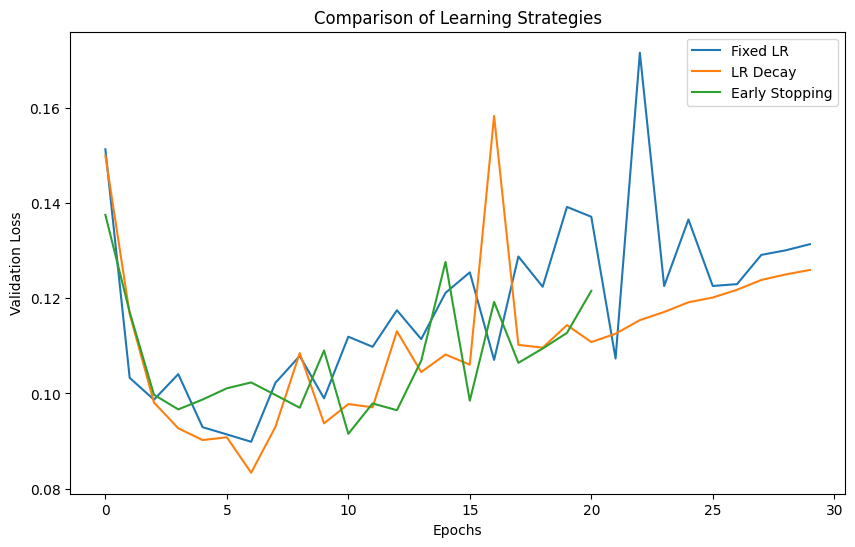

In [9]:
plt.figure(figsize=(10,6))

plt.plot(history_fixed.history['val_loss'], label="Fixed LR")
plt.plot(history_decay.history['val_loss'], label="LR Decay")
plt.plot(history_early.history['val_loss'], label="Early Stopping")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Comparison of Learning Strategies")
plt.show()
